In [26]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm 
from scipy import ndimage
from pathlib import Path
from matplotlib.lines import Line2D
import sys
from pathlib import Path

sys.path.append('..')
from eeg.stats import get_onset_latency, bootstrap_latency_ci, compare_latencies_paired, bootstrap_ci

n_samples=1000
seed=42

regression_dir = '/orcd/data/ngk/001/users/emaliem/SIEEG_analysis/data/interim/JointRegression'
out_dir = '/orcd/data/ngk/001/users/emaliem/SIEEG_analysis/data/interim/PlotFeatureDecoding'
Path(out_dir).mkdir(parents=True, exist_ok=True)

features = ['scene_object',
            'social_primitive', 'social_interaction', 
            'affective']
# title_names = ['spatial expanse', 'object directedness',
#             'agent distance', 'facingness',
#             'joint action', 'communication', 'valence', 'arousal']
colors = ['#fa7d5e', '#e95462', '#c83e73',
            '#a3307e', '#7e2482', '#59157e', '#331067', '#120d31']

In [27]:
def load_files(files):
    df = []
    for file in tqdm(files, desc='Loading files'):
        subj_df = pd.read_parquet(file)
        subj_df['eeg_subj_id'] = file.split('/')[-1].split('_')[0]
        df.append(subj_df)
    df = pd.concat(df, ignore_index=True)
    print('Finished loading files')
    return df

In [28]:
files = glob(f'{regression_dir}/*rois.parquet')
df = load_files(files)
df_avg = df.groupby(['roi_name', 'feature', 'time']).mean(numeric_only=True).reset_index()
df_avg = df_avg.pivot(index=['roi_name', 'time'], columns='feature', values='score').reset_index()
df_avg['r2_combined'] = df_avg[features].sum(axis=1)
print(df_avg.head())


Loading files: 100%|██████████| 20/20 [00:00<00:00, 141.99it/s]


Finished loading files
feature roi_name   time  affective       eeg  scene_object  \
0            EBA -200.0   0.002183  0.098771     -0.000426   
1            EBA -197.5  -0.000548  0.100975     -0.000975   
2            EBA -195.0   0.001177  0.097121     -0.000833   
3            EBA -192.5   0.003908  0.094961     -0.000008   
4            EBA -190.0   0.004323  0.096108      0.000437   

feature  social_interaction  social_primitive     total  r2_combined  
0                 -0.001623         -0.004589  0.089434    -0.004456  
1                 -0.001395         -0.004128  0.089044    -0.007046  
2                 -0.002204         -0.002740  0.087624    -0.004600  
3                 -0.003002          0.000476  0.091463     0.001374  
4                 -0.003114          0.001518  0.094421     0.003164  


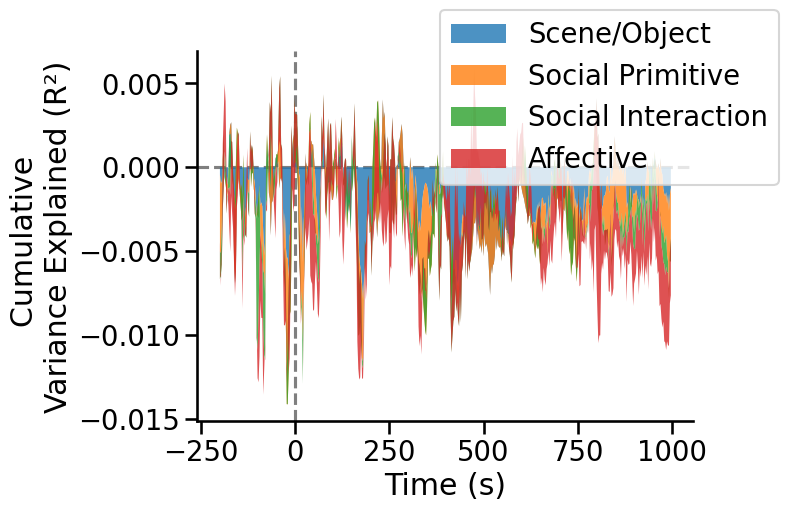

In [30]:
df_roi = df_avg[df_avg['roi_name'] == 'EBA'].reset_index(drop=True)

sns.set_context('talk', font_scale=1.2)
# ymax = np.ceil(df_roi['r2_combined'].max() * 10) / 10
_, ax = plt.subplots()
ax.stackplot(df_roi['time'],
                df_roi['scene_object'],
                df_roi['social_primitive'],
                df_roi['social_interaction'],
                df_roi['affective'],
                labels=['Scene/Object', 'Social Primitive',
                        'Social Interaction', 'Affective'],
                colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'],
                alpha=0.8,
                # labels=['language', 'vision'], 
                # colors=['blue', 'red'], alpha=0.5,
                zorder=1)
ax.axvline(x=0, color='black',
        alpha=0.5, zorder=0, linestyle='dashed')
ax.axhline(y=0, color='black',
        alpha=0.5, zorder=0, linestyle='dashed')
# ax.set_ylim([0, ymax])
# ax.set_xlim([-5, 5])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cumulative \nVariance Explained (R²)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend(bbox_to_anchor=(1.2, 1.15), loc='upper right', frameon=True)
# plt.savefig(f'{self.out_dir}/sub-{self.sid}_channel-{channel}.pdf', bbox_inches='tight')
# plt.close()

In [ ]:
plotting_stats = []
onset_stats = []
for feature, fdf in tqdm(df.groupby('feature'), desc='Calculating summary stats'):
    fdf = fdf.pivot(index='time', columns='eeg_subj_id', values='value').sort_index()
    corr_data = fdf.to_numpy()
    times = fdf.reset_index()['time'].to_numpy()
    stats = get_onset_latency(corr_data, times,
                                n_permutations=n_samples,
                                seed=seed)
    low_ci, high_ci = bootstrap_ci(corr_data, seed=seed,
                                    n_bootstrap=n_samples)
    latency_ci = bootstrap_latency_ci(corr_data, times,
                                        n_bootstrap=n_samples,
                                        n_permutations=n_samples,
                                        seed=seed)
    
    onset_stats.append({
        'feature': feature,
        'onset_latency': stats['onset_latency_ms'],
        'onset_low_ci': latency_ci[0],
        'onset_high_ci': latency_ci[1],
    })

    plotting_stats.append(pd.DataFrame({
        'feature': feature,
        'time': times,
        'score': corr_data.mean(axis=1),
        'significant_timepoints': stats['sig_timepoints'],
        'low_ci': low_ci,
        'high_ci': high_ci,
    }))
    print(feature)
df_time = pd.concat(plotting_stats, ignore_index=True)
df_onset = pd.DataFrame(onset_stats)

Loading files:   0%|          | 0/20 [00:12<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
_, axes = plt.subplots(4, 2, figsize=(7.5, 7.5), sharex=True, sharey=True)
axes = axes.flatten()
ymin, ymax = -0.15, 0.425

order_counter = 0
custom_lines = []
smooth_kernel = np.ones(10)/10
for ifeature, (_, feature_df) in enumerate(stats_df.groupby('feature', observed=True)):
    ax, color, feature = axes[ifeature], colors[ifeature], title_names[ifeature]
    order_counter +=1
    alpha = 0.1 if color == 'black' else 0.2
    alpha += 0.2 if color == '#F5DD40' else 0
    smoothed_data = {}
    for key in ['low_ci', 'high_ci', 'score']:
        smoothed_data[key] = np.convolve(feature_df[key], smooth_kernel, mode='same')

    ax.fill_between(x=feature_df['time'], 
                y1=smoothed_data['low_ci'], y2=smoothed_data['high_ci'],
                edgecolor=None, color=color, alpha=alpha, 
                zorder=order_counter)
    order_counter +=1
    ax.plot(feature_df['time'], smoothed_data['score'],
            color=color, zorder=order_counter,
            linewidth=1.5)
    custom_lines.append(Line2D([0], [0], color=color, lw=2))

    label, n = ndimage.label(feature_df['significant_timepoints'])
    onset = None
    for icluster in range(1, n+1):
        time_cluster = feature_df['time'].to_numpy()[label == icluster]
        if onset is None:
            onset = time_cluster.min()
            ax.text(x=time_cluster.min(), 
                    y=ymin+((ymax-ymin)*0.065),
                    s=f'{onset:.0f} ms',
                    fontsize=6)
        ax.hlines(y=ymin+((ymax-ymin)*0.05),
                    xmin=time_cluster.min(),
                    xmax=time_cluster.max(),
                    color=color, zorder=0, linewidth=1.5)

    ax.set_title(feature)
    ax.set_xlim([-200, 1000])
    ax.vlines(x=[0, 500], ymin=ymin, ymax=ymax,
                linestyles='dashed', colors='grey',
                linewidth=1, zorder=0)
    ax.hlines(y=0, xmin=-200, xmax=1000, colors='grey',
                linewidth=1, zorder=0)
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_ylim([ymin, ymax])
    if ifeature % 2 == 0:
        ax.set_ylabel('Prediction ($r$)')

    if ifeature >= 6:
        ax.set_xlabel('Time (ms)')

plt.tight_layout()
plt.savefig(out_file)